# 4) Stellar Spectrum Reduction

For this task, we analyse the data files flat.fits and moon.fits in the data/ folder. They contain the same 4112x385 pixel detector region around the CaII triplet. 

1. Determine the tramlines

We want to use the flat-field image to determine the tramline positions as a function of dispersion pixel and fit an appropriate smooth function. We start by importing important python packages and the data.

In [111]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.table import Table
from astropy.io import fits
from scipy.signal import find_peaks

In [6]:
with fits.open('../data/flat.fits') as hdul:
    hdul.info()
    flat_field = hdul[0].data

with fits.open('../data/moon.fits') as hdul:
    hdul.info()
    moon = hdul[0].data

Filename: ../data/flat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (385, 4112)   float64   
Filename: ../data/moon.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (385, 4112)   float64   


Before, we start with the computations, we look at the flat fields.

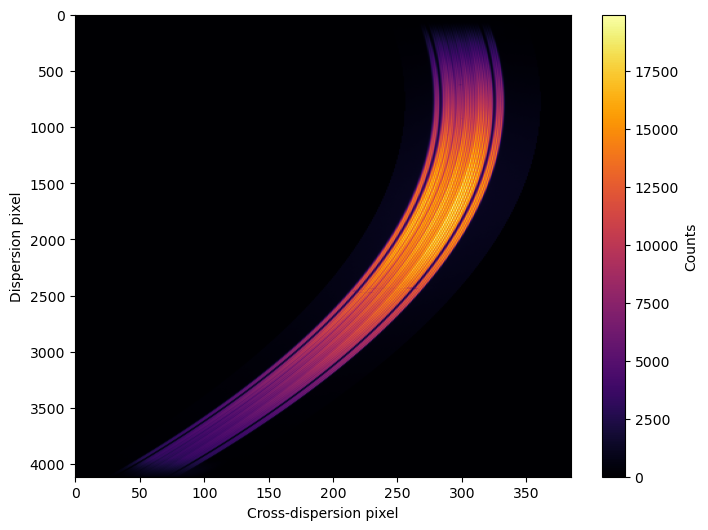

In [99]:
plt.figure(figsize=(8,6))
plt.imshow(flat_field, aspect='auto', cmap='inferno')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.colorbar(label='Counts')
plt.savefig('../figures/flat_field.png')
plt.show()

We are searching for the tramlines starting from the peak of the flat field profile. From there, we walk one row at a time to the left/right to find the corresponding tramline. For each row, we compare the number of counts to the number of counts of the peak. We stop the search when we reach a threshold of $0.35 \cdot peak$ and save this point as the tramline. The value of 0.35 was chosen after experimentation of different values. We do this for all rows of the image. We show the image with the chosen points.

In [ ]:
n_rows, n_cols = flat_field.shape
left_gap = np.full(n_rows, np.nan)
right_gap = np.full(n_rows, np.nan)

# Threshold of when we consider a point a part of the tramline
threshold_frac = 0.35

for i in range(n_rows):
    profile = flat_field[i, :]
    peak_val = np.max(profile)  # peak value of the profile
    peak_col = np.argmax(profile)  # index of peak value
    threshold = threshold_frac * peak_val  # threshold to search for

    col = peak_col  # Start search at peak value

    # Search for left tramline
    while col > 0 and profile[col] > threshold:
        col -= 1
    left_gap[i] = col

    #Search for right tramline
    col = peak_col
    while col < n_cols - 1 and profile[col] > threshold:
        col += 1
    right_gap[i] = col

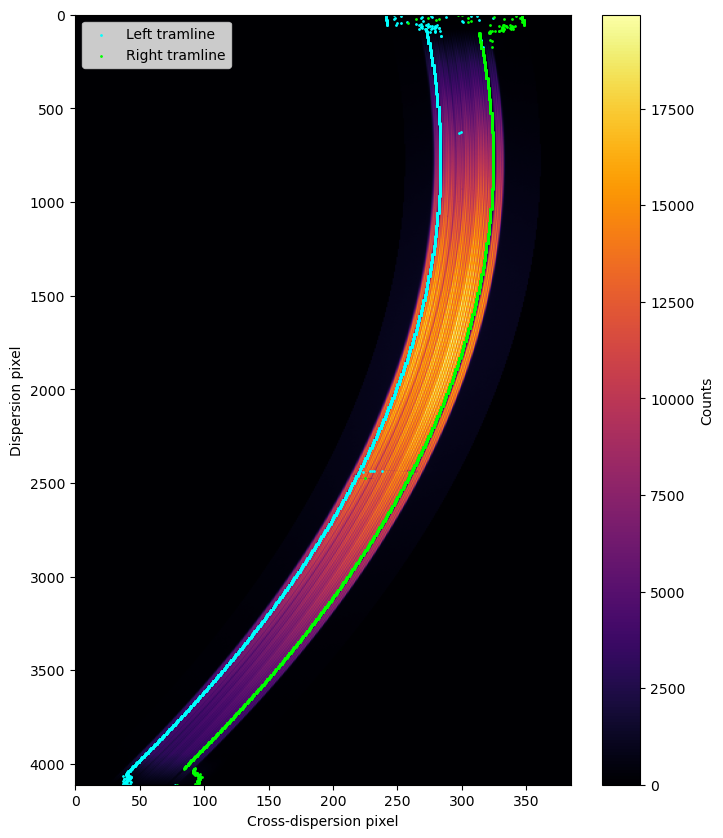

In [100]:
plt.figure(figsize=(8, 10))
plt.imshow(flat_field, aspect='auto', cmap='inferno')
plt.colorbar(label='Counts')
plt.scatter(left_gap, row_indices, color='cyan', s=1, label='Left tramline')
plt.scatter(right_gap, row_indices, color='lime', s=1, label='Right tramline')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.legend()
plt.savefig('../figures/tramlines_with_scatter.png')
plt.show()

We can see that most of the dots are indeed in the tramlines. Our method for searching the tramlines worked in most cases. However, at the corners, the method does not work as well anymore. This is because there are fewer counts here and the threshold fraction of 0.35 might be too high or too low in these regions. In the centre of the image, at very high counts, we also have some outliers because the counts are very large here. We now want to fit a smooth function through these data points. We test different orders of polynomials.

In [84]:
row_indices = np.arange(n_rows)

# Order of polynomial
poly_order = 2

# Polynomial fit with the np.polynomial function
coeffs_left = np.polyfit(row_indices, left_gap, poly_order)
coeffs_right = np.polyfit(row_indices, right_gap, poly_order)

fit_left = np.polyval(coeffs_left, row_indices)
fit_right = np.polyval(coeffs_right, row_indices)

We report the coefficients of the fit.

In [98]:
print("Coefficients of the fit for the left tramline: ", coeffs_left)
print("Coefficients of the fit for the right tramline: ", coeffs_right)

Coefficients of the fit for the left tramline:  [-2.27844178e-05  3.58395761e-02  2.68667730e+02]
Coefficients of the fit for the right tramline:  [-2.12892749e-05  2.91151611e-02  3.15617743e+02]


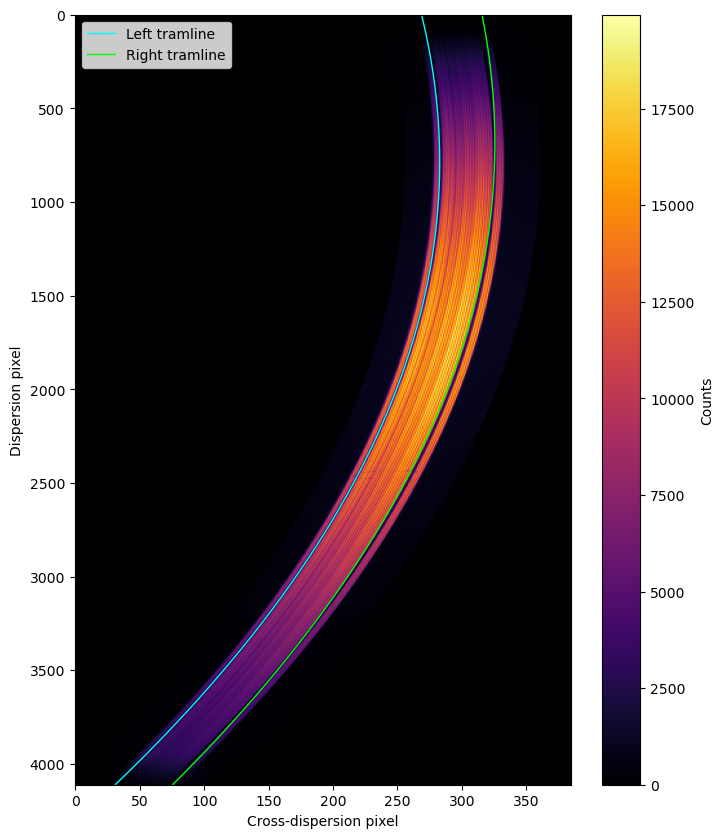

In [101]:
plt.figure(figsize=(8, 10))
plt.imshow(flat_field, aspect='auto', cmap='inferno')
plt.colorbar(label='Counts')
plt.plot(fit_left, row_indices, color='cyan', lw=1, label='Left tramline')
plt.plot(fit_right, row_indices, color='lime', lw=1, label='Right tramline')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.legend()
plt.savefig('../figures/tramlines_with_fit.png')
plt.show()

We can see that already a second-order polynomial fits the tramlines very well with only small deviations. Hence, we use a second-order polynomial as we do not expect major improvements from higher orders and want a simple model. 

2. Extract the spectrum

Now, we want to sum the counts between the tramlines to extract the flat-field and moon data. Therefore, we define a function extract_spectrum that takes an image, the left tramline and the right tramline and sums all counts between the two tramlines.

In [ ]:
# Define function to extract spectrum
def extract_spectrum(image, left_tramline, right_tramline):
    n_rows = image.shape[0]
    spectrum = np.full(n_rows, np.nan)
    for i in range(n_rows):
        left = int(np.round(left_tramline[i]))
        right = int(np.round(right_tramline[i]))
        spectrum[i] = np.sum(image[i, left:right+1])
    return spectrum

Given this function, we can compute the flat spectrum and moon spectrum by applying this function to the flat field image and moon image and the computed tramline fits from the previous task.

In [ ]:
# Compute spectrum for flat field and moon
flat_spectrum = extract_spectrum(flat_field, fit_left, fit_right)
moon_spectrum = extract_spectrum(moon, fit_left, fit_right)

Now, we take the ratio between the moon spectrum and the flat field spectrum and define the corresponding dispersion pixel.

In [ ]:
# Take the ratio
moon_flat_ratio = moon_spectrum / flat_spectrum

dispersion_pixel = np.arange(len(moon_flat_ratio))

Finally, we plot the spectrum.

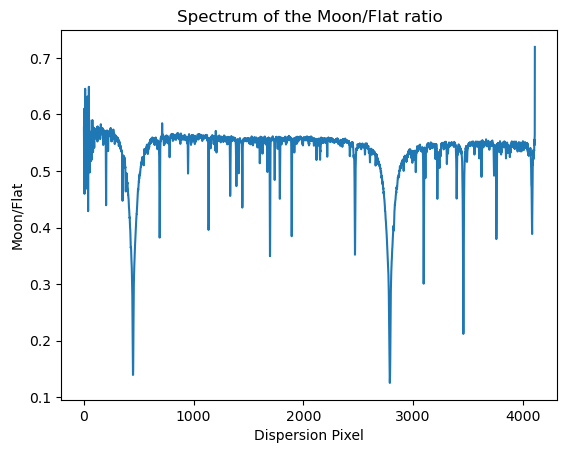

In [110]:
plt.figure()
plt.plot(dispersion_pixel, moon_flat_ratio)
plt.xlabel('Dispersion Pixel')
plt.ylabel('Moon/Flat')
plt.title('Spectrum of the Moon/Flat ratio')
plt.savefig('../figures/Spectrum_moon_flat.png')
plt.show()

We can now identify and indicate certain pixels corresponding to the CaII lines at 8498, 8542 and 8662 Å. Therefore we use the scipy.signal function find_peaks.

In [ ]:
# Invert spectrum so the absorption lines become peaks
inverted_spectrum = -moon_flat_ratio

# Find peaks
peaks, properties = find_peaks(inverted_spectrum, prominence=np.nanstd(inverted_spectrum)*5, distance=20)

print("Pixel positions of CaII: ", peaks)

Pixel positions of CaII:  [ 447 2789 3459]


We found the three largest absorption lines at the indexes 447, 2789 and 3459. As we have found a much larger gap between the first and second line than between the second and third line, the dispersion pixel axis is probably inverted. That means that the left line corresponds to the 8662 Å line, the central line to the 8542 Å line and the right one to the 8498 Å line. We add these lines to the plot.

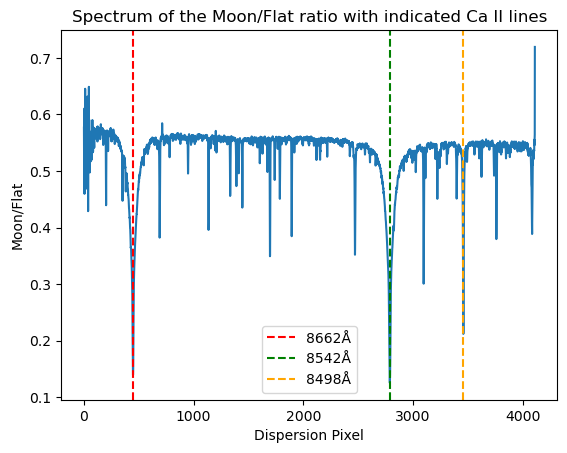

In [124]:
lines = [8662, 8542, 8498]
colors = ['red', 'green', 'orange']

plt.figure()
plt.plot(dispersion_pixel, moon_flat_ratio)
for i in range(3):
    plt.axvline(peaks[i], color=colors[i], linestyle='--', label=f'{lines[i]}Å')
plt.xlabel('Dispersion Pixel')
plt.ylabel('Moon/Flat')
plt.title('Spectrum of the Moon/Flat ratio with indicated Ca II lines')
plt.legend()
plt.savefig('../figures/Spectrum_moon_flat_Ca_lines.png')
plt.show()